In [72]:
#简化版市场法估值程序

In [73]:
#导入库
import pandas as pd
import tushare as ts

In [74]:
# 初始化pro接口
#api请自行输入
pro = ts.pro_api('api')

In [75]:
##申万行业分类表格提取
basestation ="swclass217.xlsx"
###pandas库提取excel命令.read_excel
data = pd.read_excel(basestation)
data

,交易所,行业代码,股票代码,公司简称,新版一级行业,新版二级行业,新版三级行业
0,A股,720902,600373.SH,NaN,传媒,出版,大众出版
1,A股,720902,601949.SH,中国出版,传媒,出版,大众出版
2,A股,720902,601801.SH,皖新传媒,传媒,出版,大众出版
3,A股,720902,300788.SZ,中信出版,传媒,出版,大众出版
4,A股,720902,601858.SH,中国科传,传媒,出版,大众出版
...,...,...,...,...,...,...,...
5279,美股,240301,ACH.N,中国铝业,有色金属,工业金属,铝
5280,美股,240301,5EN.SG,麦达新控股,有色金属,工业金属,铝
5281,美股,240302,NUAG.TO,NEW PACIFIC METALS,有色金属,工业金属,铜
5282,美股,240402,SVM.TO,希尔威金属矿业,有色金属,贵金属,白银


In [76]:
##设置基准日和待查上市公司名
b_date='20211231'
c_name='中兵红箭'

In [77]:
##pandas用&进行多条件'与'筛选行业名称及A股同行业公司
###选取行业
ind_name=data[(data['公司简称']==c_name)&(data['交易所']=='A股')]['新版三级行业']
###重置序号
ind_name.index=[0]
###筛选同行业公司
data[(data['新版三级行业']==ind_name[0])&(data['交易所']=='A股')]

,交易所,行业代码,股票代码,公司简称,新版一级行业,新版二级行业,新版三级行业
2682,A股,620501,002310.SZ,东方园林,建筑装饰,基础建设,园林工程
2683,A股,620501,300197.SZ,节能铁汉,建筑装饰,基础建设,园林工程
2684,A股,620501,300355.SZ,蒙草生态,建筑装饰,基础建设,园林工程
2685,A股,620501,603359.SH,东珠生态,建筑装饰,基础建设,园林工程
2686,A股,620501,002431.SZ,棕榈股份,建筑装饰,基础建设,园林工程
2687,A股,620501,002717.SZ,岭南股份,建筑装饰,基础建设,园林工程
2688,A股,620501,300536.SZ,农尚环境,建筑装饰,基础建设,园林工程
2689,A股,620501,300237.SZ,美晨生态,建筑装饰,基础建设,园林工程
2690,A股,620501,000010.SZ,美丽生态,建筑装饰,基础建设,园林工程
2691,A股,620501,002663.SZ,普邦股份,建筑装饰,基础建设,园林工程


In [ ]:
##取行业中位数乘数
###建立空存储列表
industry_ps_list=[]
industry_pe_list=[]
industry_pb_list=[]
###批量拉取数据并存入列表
for i in data[(data['新版三级行业']==ind_name[0])&(data['交易所']=='A股')]['股票代码']:
    df = pro.daily_basic(**{
        "ts_code": i,
        "trade_date": b_date,
        "start_date": "",
        "end_date": "",
        "limit": "",
        "offset": ""
    }, fields=[
        "pe_ttm",
        "pb",
        "ps_ttm"
    ])
    #print(df)
####将负市盈率填充为-1
    df=df.fillna(-1)
    industry_ps_list.append(df['ps_ttm'][0])
    industry_pe_list.append(df['pe_ttm'][0])
    industry_pb_list.append(df['pb'][0])
#print(industry_pe_list)
industry_temp=pd.DataFrame()
industry_temp['ps_ttm']=industry_ps_list
industry_temp['pe_ttm']=industry_pe_list
industry_temp['pb']=industry_pb_list
#print(industry_temp)
####使用pandas的median函数计算行业乘数中位数
industry_temp_ps=industry_temp['ps_ttm'].median()
industry_temp_pe=industry_temp['pe_ttm'].median() 
industry_temp_pb=industry_temp['pb'].median() 
industry_temp_ps,industry_temp_pe,industry_temp_pb

(2.6682, 30.6296, 1.6039)

In [ ]:
##各指标乘数估值测算
###拉取个股数据
###公司名称->代码
c_code=data[(data['公司简称']==c_name)]['股票代码']
c_code.index=[0]
###收盘价close,ps_ttm,pe_ttm,pb
df = pro.daily_basic(**{
    "ts_code": c_code[0],
    "trade_date": b_date,
    "start_date": "",
    "end_date": "",
    "limit": "",
    "offset": ""
}, fields=[
    "ts_code",
    "close",
    "pe_ttm",
    "pb",
    "ps_ttm"
])
df
###各指标乘数估值测算
price_ps=df['close'][0]*industry_temp_ps/df['ps_ttm'][0]
price_pe=df['close'][0]*industry_temp_pe/df['pe_ttm'][0]
price_pb=df['close'][0]*industry_temp_pb/df['pb'][0]
###异常处理
if price_ps<0:
    price_ps=0
if price_pe<0:
    price_pe=0
if price_pb<0:
    price_pb=0

##分行业类型和是否科创板测算市场法估值
###给出科创板、传统行业、其他行业权重

mv_weight_kcb=[]
mv_weight_tradi=[]
mv_weight_else=[0.2,0.5,0.3]
if industry_temp_pe<0:
    mv_weight_kcb=[]
    mv_weight_tradi=[]
    mv_weight_else=[0.2,0,0.8]      

###兜底估值
mv_weight=[0,0,1]
mv_basic=mv_weight[0]*price_ps+mv_weight[1]*price_pe+mv_weight[2]*price_pb
###分行业估值
###这里简化判断行业部分，请同学们自行设定分类
industry_def='分传统行业'
if industry_def=='科创板':
    mv_weight=mv_weight_kcb
    mv=mv_weight[0]*price_ps+mv_weight[1]*price_pe+mv_weight[2]*price_pb
elif industry_def=='传统行业':
    mv=mv_basic
else:
    mv_weight=mv_weight_else
    mv=mv_weight[0]*price_ps+mv_weight[1]*price_pe+mv_weight[2]*price_pb
if mv<mv_basic:
    mv=mv_basic

print(c_name+b_date+'日股价为'+str(df['close'][0])+'元,'+'市场法估值结果为'+str(round(mv,2))+'元')


东珠生态20211231日股价为14.3元,市场法估值结果为20.05元


In [ ]:
#相比个人软著的简化部分，peg等其他加权指标，智能行业分类，数据库连接，更多的异常处理

In [ ]:
#生成可视化图表

In [ ]:
#导入图表对应库
import matplotlib.pyplot as plt

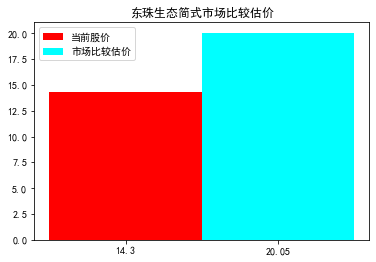

In [ ]:
# 数据可视化
##.figure创建图像
fig=plt.figure()
##显示中文字体(.rcParams)参数设置命令
plt.rcParams['font.sans-serif'] = ['SimHei']  
##处理负号显示
plt.rcParams['axes.unicode_minus'] = False  
##估价图
label_list = [df['close'][0],round(mv,2)]
num_list1 = [float(df['close'][0])]      
num_list2 = [float(round(mv,2))]      


"""
绘制条形图（.bar）
起点位置
height:长条形高度
width:长条形宽度
label:为后面设置legend准备
"""
rects1 = plt.bar(0, height=num_list1, width=0.4, color='red', label="当前股价")
rects2 = plt.bar(0.4, height=num_list2, width=0.4, color='aqua', label="市场比较估价")
"""
设置x轴刻度显示值(.xticks)
参数一：中点坐标
参数二：显示值
"""
plt.xticks([0,0.4], label_list)
plt.title(f"{c_name}简式市场比较估价")
## 设置题注
plt.legend()     

##显示图片
plt.show()
##关闭画图
plt.close()

In [ ]:
#生成excel

In [ ]:
#导入excel对应库
import xlwings as xw

In [ ]:
##创建Excel文件，并设置为不可见
app = xw.App(visible=False)
wb = app.books.add()
##创建excel工作表
sht = wb.sheets.add('project')
##写内容(.range位置.value内容，format字符串中加函数简化为f+{})
sht.range(1,1).value = f'使用市场比较估价法对{c_name}公司进行估价分析.\n\n\
(仅供参考，不作为投资依据)'
sht.range(2,1).value = f'数据来源:Tushare'
sht.range(3,1).value = f'日期:{b_date}'
price=df['close'][0]
sht.range(4,1).value = f'股价为{price}元,市场法估值结果为{str(round(mv,2))}元'
##调整格式
###.column_width宽
sht.range("A1:G100").column_width = 25
###.api.WrapText文字自动换行
sht.range("A1:A4").api.WrapText = True
###合并单元格.merge
sht.range("A1:B1").merge()
sht.range("A4:B4").merge()
###.row_height行高
sht.range("A1").row_height = 50
###设置字体边框
sht.range("A1:G100").api.Font.Size = 12          # 设置字体的大小。
sht.range("A1:G100").api.Font.Bold = True        # 设置为粗体。
sht.range("A1:B4").api.Borders(7).LineStyle = 1
sht.range("A1:B4").api.Borders(8).LineStyle = 1
sht.range("A1:B4").api.Borders(9).LineStyle = 1
sht.range("A1:B4").api.Borders(10).LineStyle = 1
###插入图片.pictures.add
sht.pictures.add(fig, name='图1', update=True, left=400)
###文件储存
wb.save(f'{c_name}估价报告.xlsx')
###关闭excel链接
wb.close()
app.quit()


